In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: C:\Users\admin\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


## 1. Import libraries
The notebook uses pandas for analysis, Matplotlib for charts, and scikit-learn for machine learning.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Libraries imported successfully')

Libraries imported successfully


## 2. Create a sample retail dataset
The sample includes date, product category, units sold, unit price, discount, weekday, promotion status, and revenue. Values are simulated for learning and are not real business records.

In [3]:
n = 1200
dates = pd.date_range('2025-01-01', periods=180, freq='D')
date = np.random.choice(dates, n)
categories = np.random.choice(['Grocery', 'Beverages', 'Personal Care', 'Household', 'Snacks'], n)
price_ranges = {'Grocery': (20, 250), 'Beverages': (15, 120), 'Personal Care': (40, 500), 'Household': (30, 350), 'Snacks': (10, 100)}
unit_price = np.array([np.random.uniform(*price_ranges[c]) for c in categories]).round(2)
units_sold = np.random.randint(1, 31, n)
discount_pct = np.random.choice([0, 5, 10, 15, 20], n, p=[.35, .15, .25, .15, .10])
promotion = np.random.choice(['No', 'Yes'], n, p=[.7, .3])
weekday = pd.to_datetime(date).day_name()
weekend_boost = pd.Series(weekday).isin(['Saturday', 'Sunday']).to_numpy() * np.random.randint(0, 6, n)
promo_boost = (promotion == 'Yes') * np.random.randint(0, 8, n)
units_sold = np.maximum(1, units_sold + weekend_boost + promo_boost - (discount_pct >= 20) * 1)
revenue = (unit_price * units_sold * (1 - discount_pct / 100)).round(2)
df = pd.DataFrame({'date': pd.to_datetime(date), 'category': categories, 'units_sold': units_sold,
                   'unit_price': unit_price, 'discount_pct': discount_pct, 'promotion': promotion,
                   'weekday': weekday, 'revenue': revenue})
df = df.sort_values('date').reset_index(drop=True)
df.to_csv('retail_sales_sample.csv', index=False)
df.head()

,date,category,units_sold,unit_price,discount_pct,promotion,weekday,revenue
0,2025-01-01,Household,29,116.53,10,No,Wednesday,3041.43
1,2025-01-01,Grocery,1,240.21,10,No,Wednesday,216.19
2,2025-01-01,Snacks,13,59.00,0,No,Wednesday,767.00
3,2025-01-01,Personal Care,17,177.10,5,Yes,Wednesday,2860.16
4,2025-01-01,Snacks,5,60.19,10,No,Wednesday,270.86


## 3. Data quality checks
Check missing values, duplicate rows, data types, and basic statistics before drawing conclusions.

In [5]:
print('Rows and columns:', df.shape)
print('\nMissing values by column:\n', df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())
display(df.describe(numeric_only = True))
display(df.head(10))

Rows and columns: (1200, 8)

Missing values by column:
 date            0
category        0
units_sold      0
unit_price      0
discount_pct    0
promotion       0
weekday         0
revenue         0
dtype: int64

Duplicate rows: 0


TypeError: NDFrame.describe() got an unexpected keyword argument 'numeric_only'

## 4. Exploratory data analysis (EDA)
Summarize revenue by category and by weekday. These results help explain where sales are concentrated.

,category,total_revenue,total_units
3,Personal Care,1020018.14,3981
2,Household,788459.47,4312
1,Grocery,504728.74,3990
0,Beverages,284425.97,4524
4,Snacks,232463.22,4591


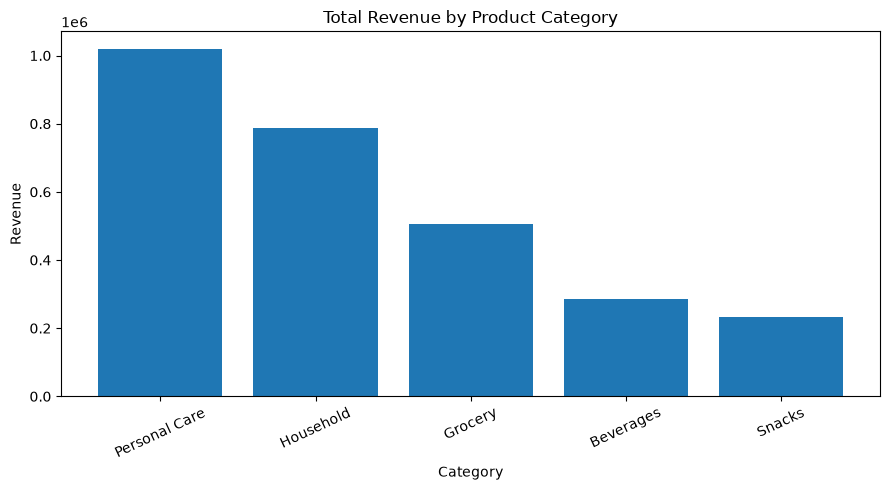

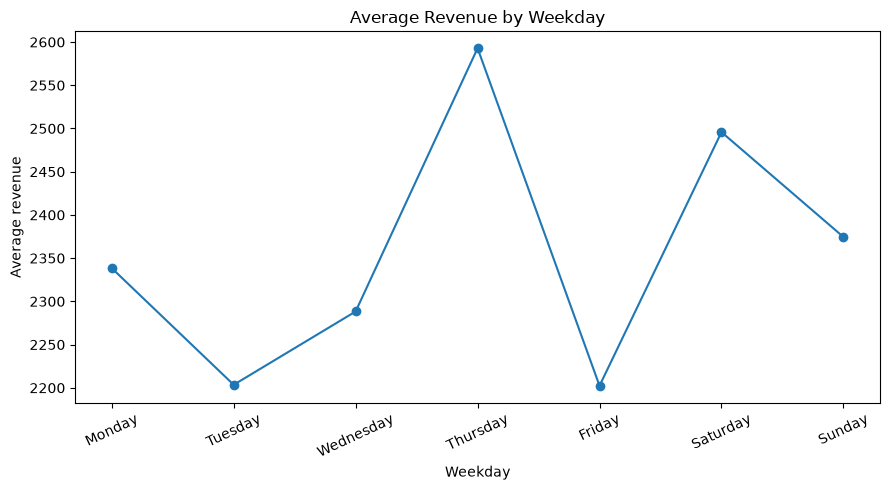

In [6]:
category_sales = df.groupby('category', as_index=False).agg(total_revenue=('revenue','sum'), total_units=('units_sold','sum'))
category_sales = category_sales.sort_values('total_revenue', ascending=False)
display(category_sales)
plt.figure(figsize=(9, 5))
plt.bar(category_sales['category'], category_sales['total_revenue'])
plt.title('Total Revenue by Product Category')
plt.xlabel('Category'); plt.ylabel('Revenue')
plt.xticks(rotation=25); plt.tight_layout(); plt.show()

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_sales = df.groupby('weekday')['revenue'].mean().reindex(weekday_order)
plt.figure(figsize=(9, 5))
plt.plot(weekday_sales.index, weekday_sales.values, marker='o')
plt.title('Average Revenue by Weekday')
plt.xlabel('Weekday'); plt.ylabel('Average revenue')
plt.xticks(rotation=25); plt.tight_layout(); plt.show()

## 5. Train an AI/ML sales prediction model
A Random Forest regression model estimates revenue using category, units sold, price, discount, promotion, and weekday. A held-out test set is used to evaluate performance. Because the data is synthetic, scores only demonstrate the workflow and should not be presented as real-world business accuracy.

In [7]:
features = ['category', 'units_sold', 'unit_price', 'discount_pct', 'promotion', 'weekday']
target = 'revenue'
X = df[features]
y = df[target]
categorical_features = ['category', 'promotion', 'weekday']
numeric_features = ['units_sold', 'unit_price', 'discount_pct']
preprocessor = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
                                   ('num', 'passthrough', numeric_features)])
model = Pipeline([('preprocessor', preprocessor),
                  ('regressor', RandomForestRegressor(n_estimators=150, random_state=RANDOM_STATE, min_samples_leaf=2))])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.3f}')

MAE: 158.76
RMSE: 315.53
R²: 0.986


## 6. Compare actual and predicted revenue
A close scatter around the diagonal indicates predictions are closer to actual values.

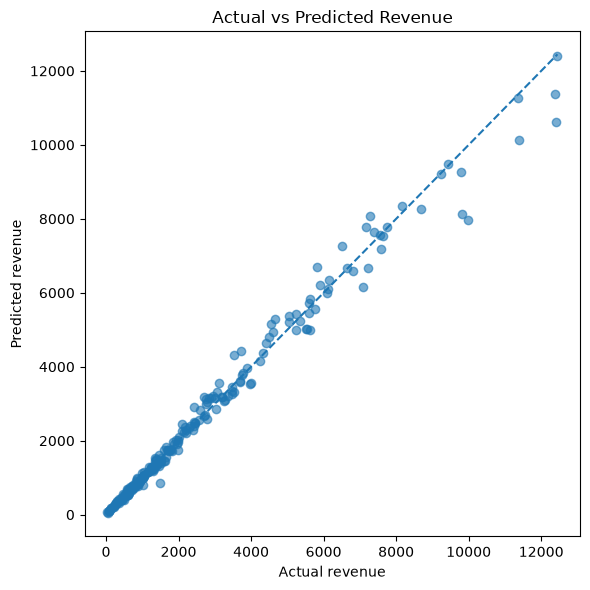

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.6)
low = min(y_test.min(), predictions.min()); high = max(y_test.max(), predictions.max())
plt.plot([low, high], [low, high], linestyle='--')
plt.title('Actual vs Predicted Revenue')
plt.xlabel('Actual revenue'); plt.ylabel('Predicted revenue')
plt.tight_layout(); plt.show()

## 7. Try a prediction for a new sale
Change the sample inputs below to explore how the model behaves.

In [9]:
new_sale = pd.DataFrame([{'category':'Grocery', 'units_sold':12, 'unit_price':85.0,
                         'discount_pct':10, 'promotion':'Yes', 'weekday':'Saturday'}])
estimated_revenue = model.predict(new_sale)[0]
print(f'Estimated revenue: ₹{estimated_revenue:,.2f}')

Estimated revenue: ₹925.29
